In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("Online Retail.xlsx")

# Data Understanding

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

The dataset contains 541,909 rows and 8 columns. It includes information about invoices, products, quantities, prices, customers, dates, and countries. The dataset contains missing values in Description and CustomerID columns and 5,268 duplicate rows. There are 25,900 unique invoices, 4,070 product codes, 4,372 customers, and customers from 38 countries. Negative values in Quantity and UnitPrice were also identified and may represent returns or cancellations.

 # Data Cleaning

In [ ]:
df_clean = df.copy()

In [ ]:
df_clean = df_clean.drop_duplicates()

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [ ]:
df_clean = df_clean.dropna(subset=["Description"])

In [ ]:
df_clean["Description"] = df_clean["Description"].str.strip()

In [ ]:
df_clean.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [ ]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [ ]:
df_clean["IsCancelled"] = df_clean["InvoiceNo"].astype(str).str.startswith("C")

In [ ]:
df_clean["IsReturn"] = df_clean["Quantity"] < 0

In [ ]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancelled,IsReturn
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,False


In [ ]:
df_clean.shape

(535187, 11)

In [ ]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description         1
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133583
Country             0
Revenue             0
IsCancelled         0
IsReturn            0
dtype: int64

The dataset was cleaned by removing duplicate rows and records with missing product descriptions. Extra spaces were removed from product descriptions. Missing CustomerID values were retained to avoid losing a large amount of transaction data. New columns were created to calculate Revenue and identify cancelled and returned transactions

# Sales Performance Analysis


In [ ]:
#Question 1: What is the total revenue generated by the store

total_revenue = df_clean["Revenue"].sum()
total_revenue

np.float64(9726006.954)

In [ ]:
# Question 2: What is the total number of orders

total_orders = df_clean["InvoiceNo"].nunique()
total_orders

24446

In [ ]:
# Question 3: What is the number of orders per month

df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M")
orders_per_month = df_clean.groupby("Month")["InvoiceNo"].nunique()
orders_per_month

Month
2010-12    1900
2011-01    1362
2011-02    1328
2011-03    1818
2011-04    1518
2011-05    2024
2011-06    1921
2011-07    1772
2011-08    1655
2011-09    2228
2011-10    2533
2011-11    3387
2011-12    1000
Freq: M, Name: InvoiceNo, dtype: int64

In [ ]:
# Question 4: How does revenue change from month to month?

revenue_per_month = df_clean.groupby("Month")["Revenue"].sum()
revenue_per_month

Month
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     681386.460
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Freq: M, Name: Revenue, dtype: float64

In [ ]:
# Question 5: Which month generated the highest revenue?

highest_revenue_month = revenue_per_month.idxmax()
highest_revenue = revenue_per_month.max()
highest_revenue_month, highest_revenue

(Period('2011-11', 'M'), np.float64(1456145.8))

In [ ]:
# Question 6: What is the Average Order Value?

average_order_value = df_clean["Revenue"].sum() / df_clean["InvoiceNo"].nunique()
average_order_value

np.float64(397.85678450462245)

In [ ]:
# Question 7: What is the average number of products per order?

average_products_per_order = df_clean.groupby("InvoiceNo")["Quantity"].sum().mean()
average_products_per_order

np.float64(211.73652131228013)

#### Country Analysis

In [ ]:
# Question 8: Which countries generate the highest revenue?

revenue_by_country = df_clean.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
revenue_by_country

Country
United Kingdom          8167128.184
Netherlands              284661.540
EIRE                     262993.380
Germany                  221509.470
France                   197317.110
Australia                137009.770
Switzerland               56363.050
Spain                     54756.030
Belgium                   40910.960
Sweden                    36585.410
Japan                     35340.620
Norway                    35163.460
Portugal                  29302.970
Finland                   22326.740
Channel Islands           20076.390
Denmark                   18768.140
Italy                     16890.510
Cyprus                    12858.760
Austria                   10154.320
Hong Kong                  9908.240
Singapore                  9120.390
Israel                     7901.970
Poland                     7213.140
Unspecified                4740.940
Greece                     4710.520
Iceland                    4310.000
Canada                     3666.380
Malta               

In [ ]:
# Question 9: Which countries have the highest number of orders?

orders_by_country = df_clean.groupby("Country")["InvoiceNo"].nunique().sort_values(ascending=False)
orders_by_country

Country
United Kingdom          22040
Germany                   603
France                    461
EIRE                      360
Belgium                   119
Spain                     105
Netherlands               101
Switzerland                74
Portugal                   71
Australia                  69
Italy                      55
Finland                    48
Sweden                     46
Norway                     40
Channel Islands            33
Japan                      28
Poland                     24
Denmark                    21
Cyprus                     20
Austria                    19
Hong Kong                  15
Unspecified                13
Malta                      10
Singapore                  10
Israel                      9
Iceland                     7
USA                         7
Greece                      6
Canada                      6
Czech Republic              5
European Community          5
Bahrain                     4
Lithuania                   4
Un

In [ ]:
# Question 10: What is the contribution of the Top 5 Countries to total revenue?

top_5_countries_revenue = revenue_by_country.head(5).sum()
total_revenue = df_clean["Revenue"].sum()

top_5_countries_percentage = (top_5_countries_revenue / total_revenue) * 100
top_5_countries_percentage

np.float64(93.9091420271259)

In [ ]:
# Question 11: Which countries have the highest Returns/Cancellations rate?

returns_by_country = df_clean.groupby("Country")["IsReturn"].mean() * 100
returns_by_country.sort_values(ascending=False)

Country
USA                     38.487973
Czech Republic          16.666667
Malta                   11.811024
Japan                   10.335196
Saudi Arabia            10.000000
Australia                5.882353
Italy                    5.603985
Bahrain                  5.263158
Germany                  4.778481
EIRE                     3.677908
Poland                   3.225806
Singapore                3.056769
Sweden                   2.386117
Denmark                  2.313625
Spain                    1.898734
Belgium                  1.836636
Switzerland              1.755266
France                   1.732818
United Kingdom           1.696853
European Community       1.639344
Finland                  1.438849
Hong Kong                1.408451
Channel Islands          1.321004
Cyprus                   1.309329
Norway                   1.289134
Portugal                 1.192053
Austria                  0.748130
Greece                   0.684932
Israel                   0.680272
Nether

In [ ]:
cancellations_by_country = df_clean.groupby("Country")["IsCancelled"].mean() * 100
cancellations_by_country.sort_values(ascending=False)

Country
USA                     38.487973
Czech Republic          16.666667
Malta                   11.811024
Japan                   10.335196
Saudi Arabia            10.000000
Australia                5.882353
Italy                    5.603985
Bahrain                  5.263158
Germany                  4.778481
EIRE                     3.677908
Poland                   3.225806
Singapore                3.056769
Sweden                   2.386117
Denmark                  2.313625
Spain                    1.898734
Belgium                  1.836636
Switzerland              1.755266
France                   1.732818
European Community       1.639344
United Kingdom           1.599890
Finland                  1.438849
Hong Kong                1.408451
Channel Islands          1.321004
Cyprus                   1.309329
Norway                   1.289134
Portugal                 1.192053
Austria                  0.748130
Greece                   0.684932
Israel                   0.680272
Nether

#### Product Analysis

In [ ]:
sales_data = df_clean[df_clean["Quantity"] > 0]

In [ ]:
# Question 12: What are the Top 10 products by quantity sold?

top_10_products_quantity = sales_data.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_10_products_quantity

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48375
WHITE HANGING HEART T-LIGHT HOLDER    37876
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [ ]:
# Question 13: What are the Top 10 products by revenue?

top_10_products_revenue = sales_data.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_10_products_revenue

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [ ]:
# Question 14: Which products have the highest Average Unit Price?

average_price_by_product = sales_data.groupby("Description")["UnitPrice"].mean().sort_values(ascending=False).head(10)
average_price_by_product

Description
AMAZON FEE                            6880.545000
PICNIC BASKET WICKER 60 PIECES         649.500000
DOTCOM POSTAGE                         291.311822
Manual                                 229.415728
RUSTIC  SEVENTEEN DRAWER SIDEBOARD     158.076923
REGENCY MIRROR WITH SHUTTERS           156.428571
VINTAGE BLUE KITCHEN CABINET           146.750000
VINTAGE RED KITCHEN CABINET            143.421053
CHEST NATURAL WOOD 20 DRAWERS          118.076923
LOVE SEAT ANTIQUE WHITE METAL          114.024390
Name: UnitPrice, dtype: float64

In [ ]:
# Question 15: What is the contribution of the Top 10 Products to total revenue?

top_10_products_total_revenue = top_10_products_revenue.sum()
total_sales_revenue = sales_data["Revenue"].sum()

top_10_products_percentage = (top_10_products_total_revenue / total_sales_revenue) * 100
top_10_products_percentage

np.float64(10.858227550674018)

In [ ]:
# Question 16: Which products are returned or cancelled the most?

returned_products = df_clean[df_clean["IsReturn"] == True]
most_returned_products = returned_products.groupby("Description")["Quantity"].sum().abs().sort_values(ascending=False).head(10)
most_returned_products

Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
printing smudges/thrown away           19200
Unsaleable, destroyed.                 15644
check                                  13247
?                                       9496
ROTATING SILVER ANGELS T-LIGHT HLDR     9376
Printing smudges/thrown away            9058
Damaged                                 7540
throw away                              5368
Name: Quantity, dtype: int64

#### Customer Analysis

In [ ]:
# Question 17: How many unique customers are in the dataset?

unique_customers = df_clean["CustomerID"].nunique()
unique_customers

4372

In [ ]:
customer_data = df_clean.dropna(subset=["CustomerID"])

In [ ]:
# Question 18: Which customers generate the highest revenue?

top_customers = customer_data.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)
top_customers

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: Revenue, dtype: float64

In [ ]:
# Question 19: What is the average revenue per customer?

revenue_per_customer = customer_data.groupby("CustomerID")["Revenue"].sum()
average_revenue_per_customer = revenue_per_customer.mean()
average_revenue_per_customer

np.float64(1893.5314327538883)

#### Returns & Cancellations Analysis

In [ ]:
# Question 20: What is the Returns rate from total transactions?

total_transactions = len(df_clean)
total_returns = df_clean["IsReturn"].sum()
returns_rate = (total_returns / total_transactions) * 100
returns_rate

np.float64(1.8171218658151262)

In [ ]:
# Question 21: What is the Cancellations rate from total transactions?

total_cancellations = df_clean["IsCancelled"].sum()
cancellations_rate = (total_cancellations / total_transactions) * 100
cancellations_rate

np.float64(1.7285546920982757)

In [ ]:
# Question 22: How do Returns and Cancellations affect total revenue?

total_revenue = df_clean["Revenue"].sum()
returns_revenue = df_clean[df_clean["IsReturn"] == True]["Revenue"].sum()
cancellations_revenue = df_clean[df_clean["IsCancelled"] == True]["Revenue"].sum()
total_revenue, returns_revenue, cancellations_revenue

(np.float64(9726006.954), np.float64(-893979.73), np.float64(-893979.73))

# Data Visualization

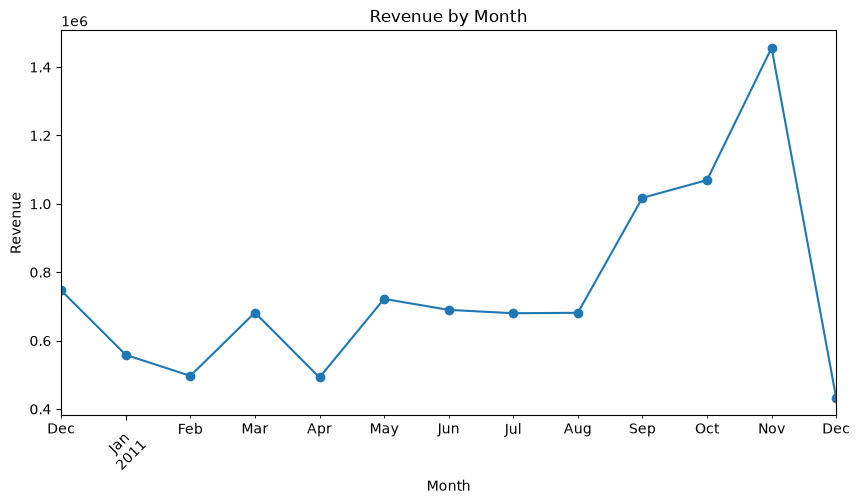

In [ ]:
# Revenue by Month
plt.figure(figsize=(10, 5))

revenue_per_month.plot(kind="line", marker="o")

plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

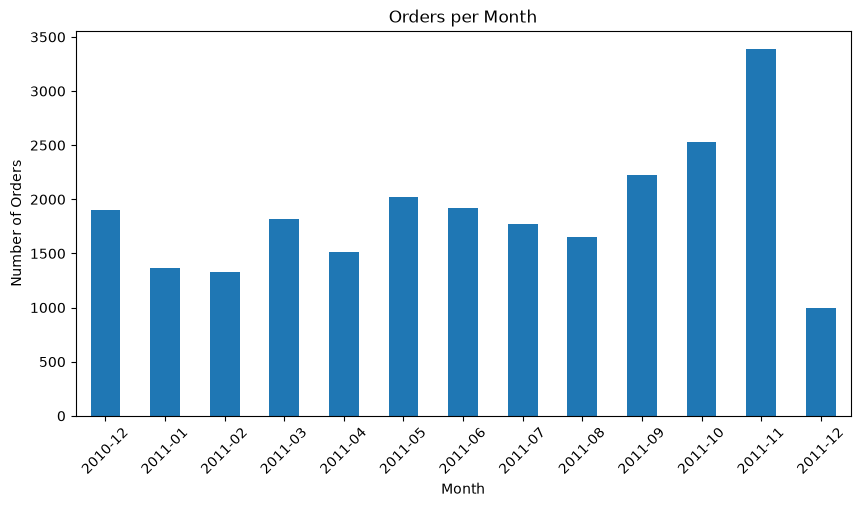

In [ ]:
# Orders by Month
plt.figure(figsize=(10, 5))

orders_per_month.plot(kind="bar")

plt.title("Orders per Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

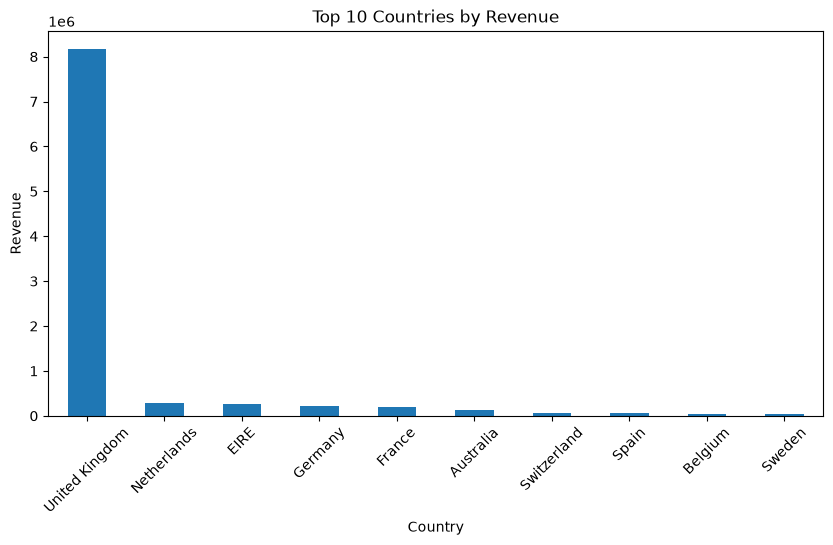

In [ ]:
# Top 10 Countries by Revenue
top_10_countries = revenue_by_country.head(10)

plt.figure(figsize=(10, 5))

top_10_countries.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

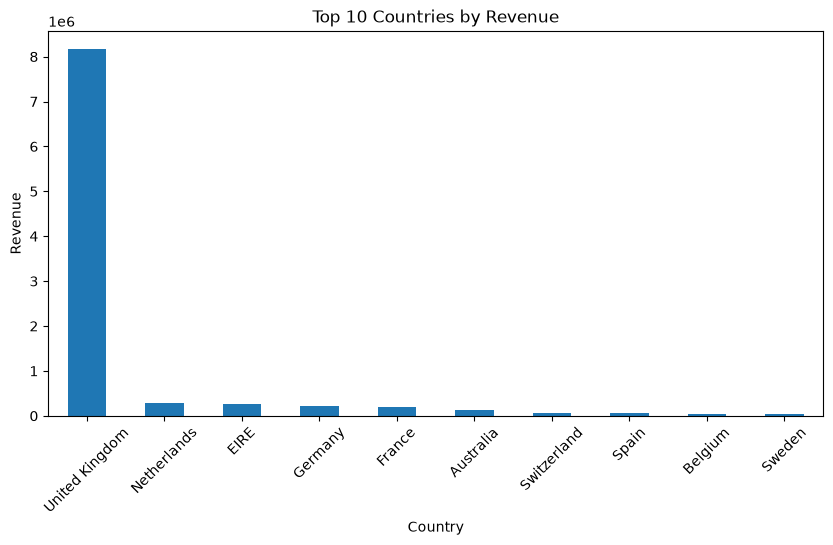

In [ ]:
#Top 10 Countries by Revenue
top_10_countries = revenue_by_country.head(10)

plt.figure(figsize=(10, 5))

top_10_countries.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

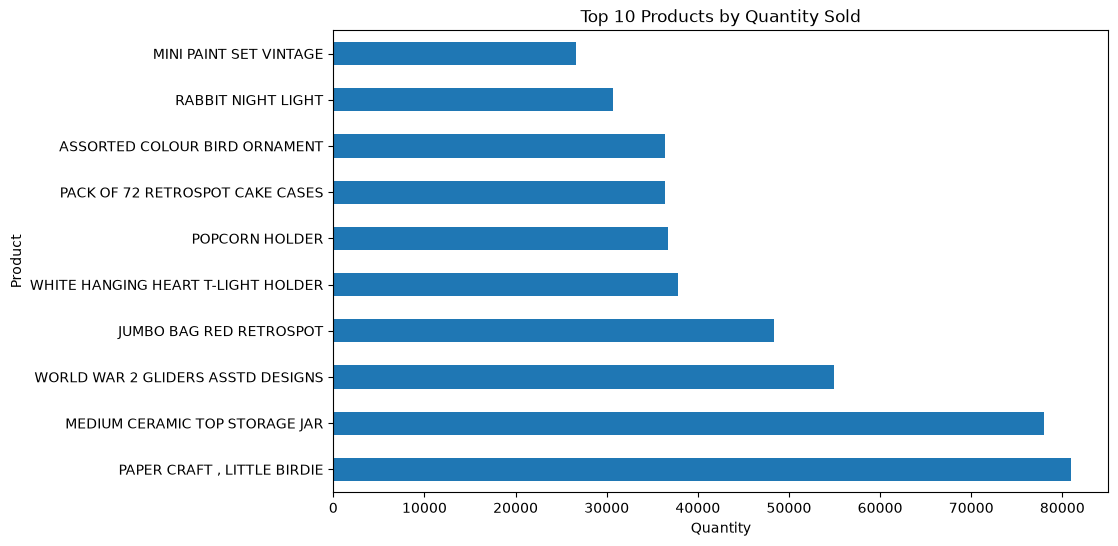

In [ ]:
#Top 10 Products by Quantity Sold
plt.figure(figsize=(10, 6))

top_10_products_quantity.plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Product")

plt.show()

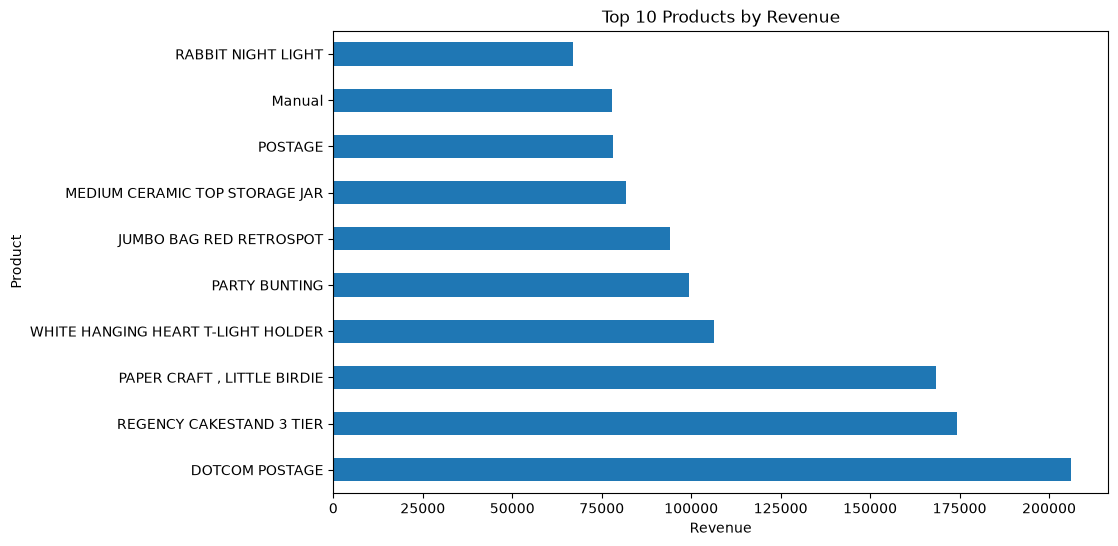

In [ ]:
# Top 10 Products by Revenue
plt.figure(figsize=(10, 6))

top_10_products_revenue.plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

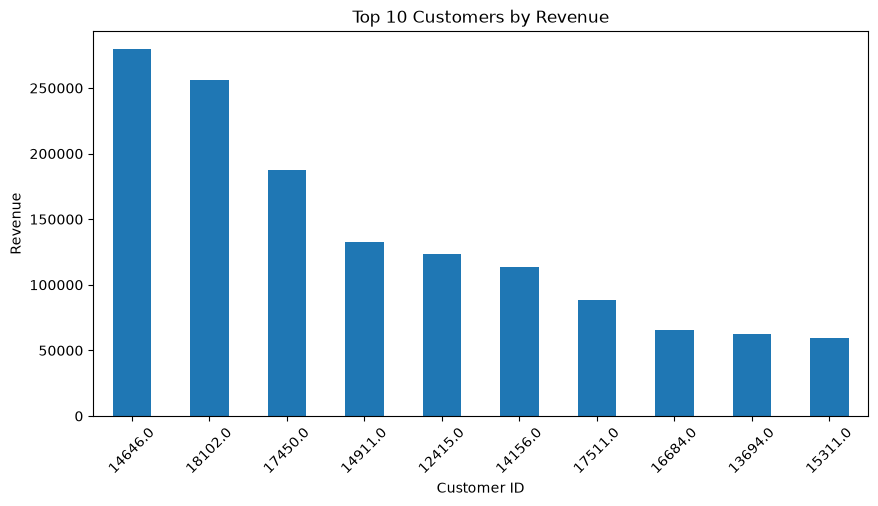

In [ ]:
#Top 10 Customers by Revenue
plt.figure(figsize=(10, 5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()